<a href="https://colab.research.google.com/github/gavin-hecke/Gavin_INFO5731_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx
import warnings

warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()  # upload bread_basket.csv here

df = pd.read_csv('bread_basket.csv')
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

KeyboardInterrupt: 

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [25]:
# write your answer here
print('=== Column names and data types ===')
print(df.dtypes)
print(f'\nShape: {df.shape}')
print(f'Unique transactions: {df["transaction"].nunique():,}')
print(f'Unique items: {df["item"].nunique()}')

=== Column names and data types ===
transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object

Shape: (20507, 6)
Unique transactions: 9,465
Unique items: 94


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [16]:
# write your answer here
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

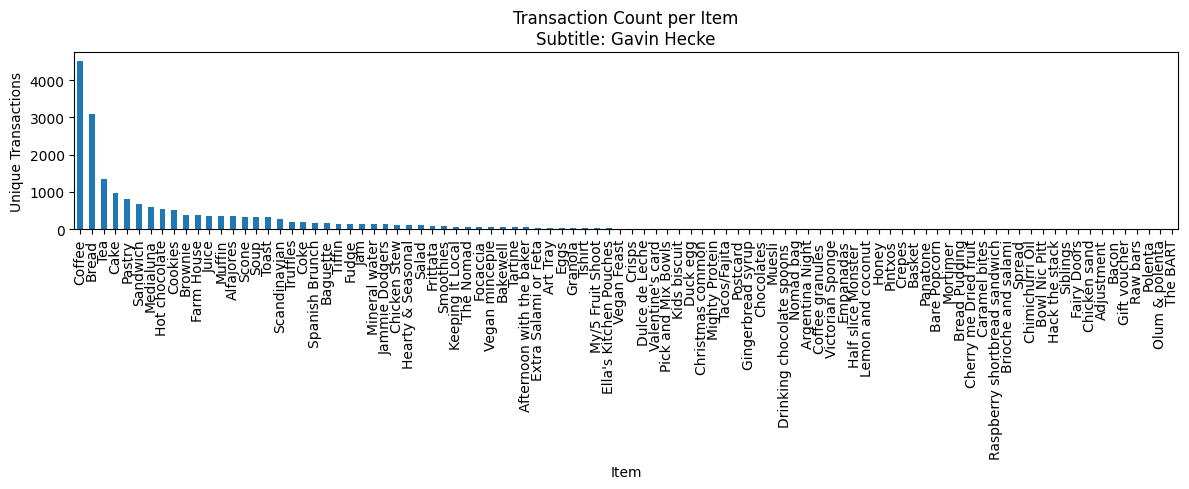

In [17]:
# c) Bar plot of transaction counts per item
subtitle = "Gavin Hecke"
item_counts = (
    df.groupby('item')['transaction']
      .nunique()
      .sort_values(ascending=False)
)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [18]:
# write your answer here
target_items = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']
counts_df = item_counts.reindex(target_items).rename('Unique Transactions').reset_index()
counts_df.columns = ['Item', 'Unique Transactions']
print(counts_df.to_string(index=False))

        Item  Unique Transactions
      Coffee                 4528
         Tea                 1350
   Alfajores                  344
       Juice                  365
Chicken Stew                  123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [26]:
# write your answer here
transactions = df.groupby('transaction')['item'].apply(list).tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

# Run at min_support=0.2 as required
frequent_itemsets = fpgrowth(basket_df, min_support=0.2, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print("Frequent itemsets at min_support=0.20:")
print(frequent_itemsets.sort_values('support', ascending=False).to_string(index=False))
print("\nNOTE: Only Coffee and Bread qualify at 0.20 — lowering to 0.01 for rules.")

frequent_itemsets_01 = fpgrowth(basket_df, min_support=0.01, use_colnames=True)
frequent_itemsets_01['length'] = frequent_itemsets_01['itemsets'].apply(len)
print(f"\nFrequent itemsets at min_support=0.01: {len(frequent_itemsets_01)} total")
frequent_itemsets_01.sort_values('support', ascending=False).head(20)

Frequent itemsets at min_support=0.20:
 support itemsets  length
0.478394 (Coffee)       1
0.327205  (Bread)       1

NOTE: Only Coffee and Bread qualify at 0.20 — lowering to 0.01 for rules.

Frequent itemsets at min_support=0.01: 61 total


,support,itemsets,length
6,0.478394,(Coffee),1
0,0.327205,(Bread),1
9,0.142631,(Tea),1
16,0.103856,(Cake),1
30,0.090016,"(Coffee, Bread)",2
7,0.086107,(Pastry),1
18,0.071844,(Sandwich),1
8,0.061807,(Medialuna),1
2,0.058320,(Hot chocolate),1
46,0.054728,"(Cake, Coffee)",2


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

Total rules: 19


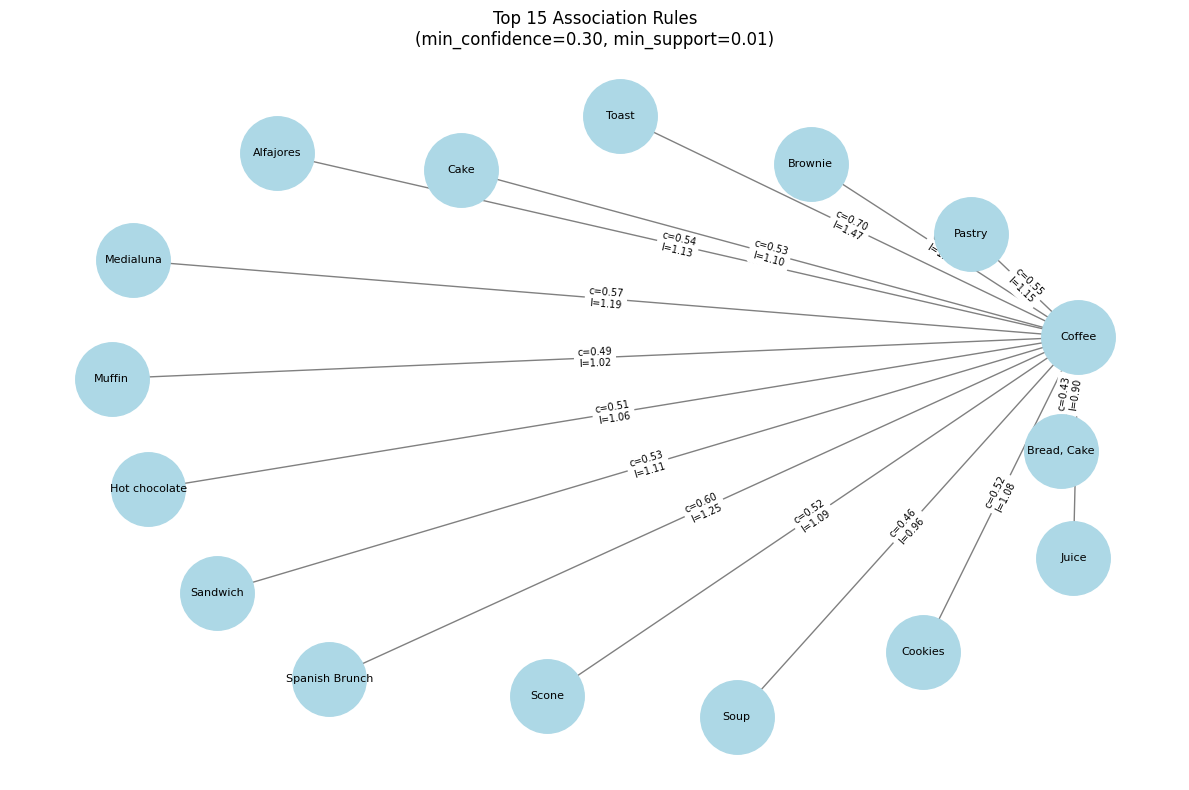

In [24]:
# write your answer here

rules_df = association_rules(frequent_itemsets_01, metric='confidence', min_threshold=0.30)
rules_df = rules_df[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_df = rules_df.sort_values('confidence', ascending=False).reset_index(drop=True)
print(f'Total rules: {len(rules_df)}')
rules_df

top_rules = rules_df.head(15)

G = nx.DiGraph()
for _, row in top_rules.iterrows():
    ant = ', '.join(sorted(row['antecedents']))
    con = ', '.join(sorted(row['consequents']))
    G.add_edge(ant, con, weight=row['confidence'], lift=row['lift'])

fig, ax = plt.subplots(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=2.5)
nx.draw_networkx_nodes(G, pos, node_size=2800, node_color='lightblue', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
edge_labels = {(u, v): f"c={d['weight']:.2f}\nl={d['lift']:.2f}" for u,v,d in G.edges(data=True)}
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, edge_color='gray', ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, ax=ax)
ax.set_title('Top 15 Association Rules\n(min_confidence=0.30, min_support=0.01)', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

Support = 0.0100 (1%)
About 1 in every 100 transactions contains Coffee, Cake, and Bread together. This means the three items co-occur rarely in absolute terms — only 95 out of 9,465 total baskets include all three.
Confidence = 0.1834 (18.3%)
Among all customers who bought both Coffee and Cake, only about 18% also picked up Bread in the same visit. So knowing someone bought Coffee and Cake does not strongly predict they will also buy Bread.
Lift = 0.56 (less than 1) — Negative Association
A lift below 1 means Coffee and Cake buyers are actually less likely to buy Bread than a random customer. Bread's overall purchase rate is about 33%, but it drops to only 18% among Coffee and Cake buyers. This tells us the rule goes against the general trend — customers in a "treat" mindset (buying Coffee and Cake) tend to skip staple items like Bread.
Practical Meaning:
This is not a useful cross-sell rule. A bakery should not bundle Bread promotions with Coffee and Cake purchases because those customers are actively buying less Bread than average. A much better rule to act on is {Toast} ⇒ {Coffee}, which has a lift of 1.47 — meaning Toast buyers buy Coffee at a higher rate than the general customer, making it a genuine and actionable product pairing.


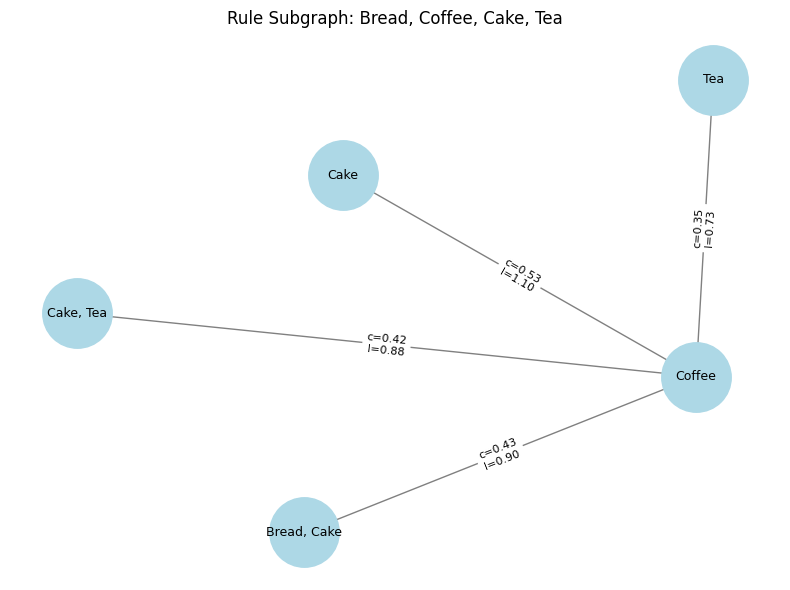

In [27]:
focus_items = {'Bread', 'Coffee', 'Cake', 'Tea'}

G_sub = nx.DiGraph()
for _, row in rules_df.iterrows():
    ant = set(row['antecedents'])
    con = set(row['consequents'])
    if ant.issubset(focus_items) and con.issubset(focus_items):
        ant_str = ', '.join(sorted(ant))
        con_str = ', '.join(sorted(con))
        G_sub.add_edge(ant_str, con_str,
                       weight=row['confidence'],
                       lift=row['lift'])

fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(G_sub, seed=42)
nx.draw_networkx_nodes(G_sub, pos, node_size=2500, node_color='lightblue', ax=ax)
nx.draw_networkx_labels(G_sub, pos, font_size=9, ax=ax)
edge_labels = {(u, v): f"c={d['weight']:.2f}\nl={d['lift']:.2f}"
               for u, v, d in G_sub.edges(data=True)}
nx.draw_networkx_edges(G_sub, pos, arrows=True, arrowsize=20, edge_color='gray', ax=ax)
nx.draw_networkx_edge_labels(G_sub, pos, edge_labels, font_size=8, ax=ax)
ax.set_title('Rule Subgraph: Bread, Coffee, Cake, Tea', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()